In [ ]:
import pandas as pd
import re
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv('/content/Tweets.csv')
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https\S+|www.\S+', '', text)
    text = re.sub(r'@\w+', '',text)
    text = re.sub(r'[^a-zA-Z\s]', '',text)
    text = re.sub(r'\s+',' ',text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

print(df[['text', 'clean_text']].head(5))

                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                          clean_text  
0                                          what said  
1  plus youve added commercials to the experience...  
2  i didnt today must mean i need to take another...  
3  its really aggressive to blast obnoxious enter...  
4            and its a really big bad thing about it  


In [ ]:
!pip install textblob

In [ ]:
def get_polarity(text):
  return TextBlob(text).sentiment.polarity

df['polarity'] = df['clean_text'].apply(get_polarity)

def label_sentiment(polarity):
  if polarity > 0:
    return 'positive'
  elif polarity < 0:
    return 'negative'
  else:
    return 'neutral'

df['predicted_sentiment'] = df['polarity'].apply(label_sentiment)
print(df[['clean_text', 'polarity', 'predicted_sentiment', 'airline_sentiment']].head(10))

                                          clean_text  polarity  \
0                                          what said  0.000000   
1  plus youve added commercials to the experience...  0.000000   
2  i didnt today must mean i need to take another... -0.312500   
3  its really aggressive to blast obnoxious enter...  0.006250   
4            and its a really big bad thing about it -0.350000   
5  seriously would pay a flight for seats that di... -0.208333   
6  yes nearly every time i fly vx this ear worm w...  0.450000   
7  really missed a prime opportunity for men with...  0.200000   
8                         well i didntbut now i do d  0.000000   
9  it was amazing and arrived an hour early youre...  0.466667   

  predicted_sentiment airline_sentiment  
0             neutral           neutral  
1             neutral          positive  
2            negative           neutral  
3            positive          negative  
4            negative          negative  
5            negative

/tmp/ipython-input-39-309408320.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


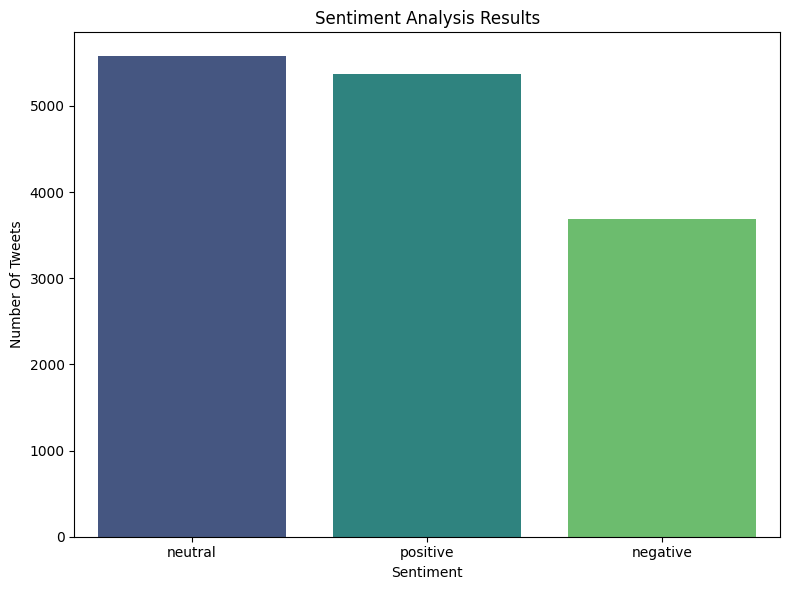

In [ ]:
sentiment_counts = df['predicted_sentiment'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Sentiment Analysis Results')
plt.xlabel('Sentiment')
plt.ylabel('Number Of Tweets')
plt.tight_layout()
plt.show()

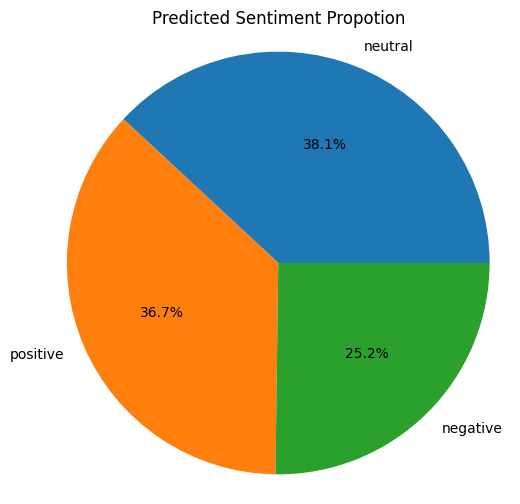

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title('Predicted Sentiment Propotion')
plt.axis('equal')
plt.show()

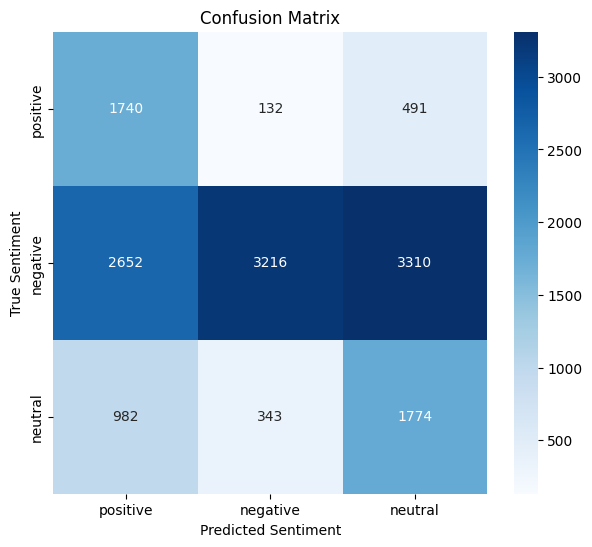

In [ ]:
lables = ['positive', 'negative', 'neutral']

cm = confusion_matrix(df['airline_sentiment'], df['predicted_sentiment'], labels=lables)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lables, yticklabels=lables)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df['airline_sentiment'], df['predicted_sentiment'])
print(f"Accuracy of TextBlob Predictions: {accuracy:.2f}")

Accuracy of TextBlob Predictions: 0.46


In [ ]:
!pip install wordcloud

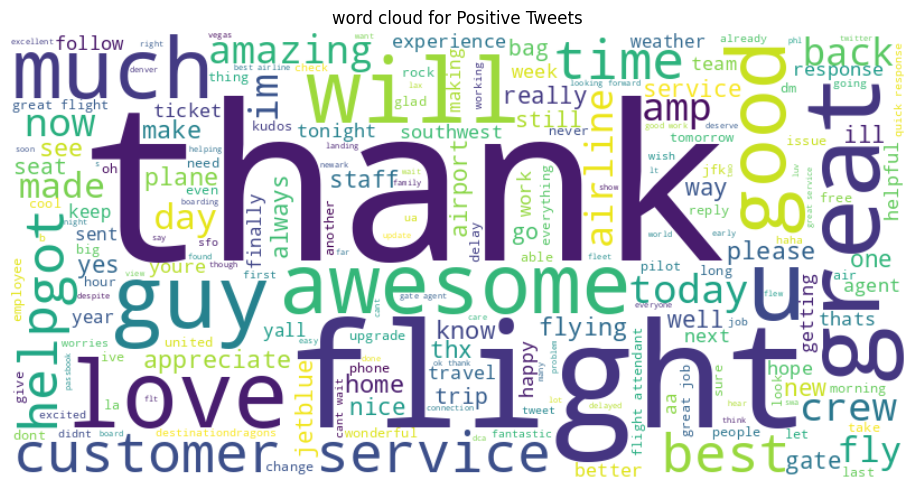

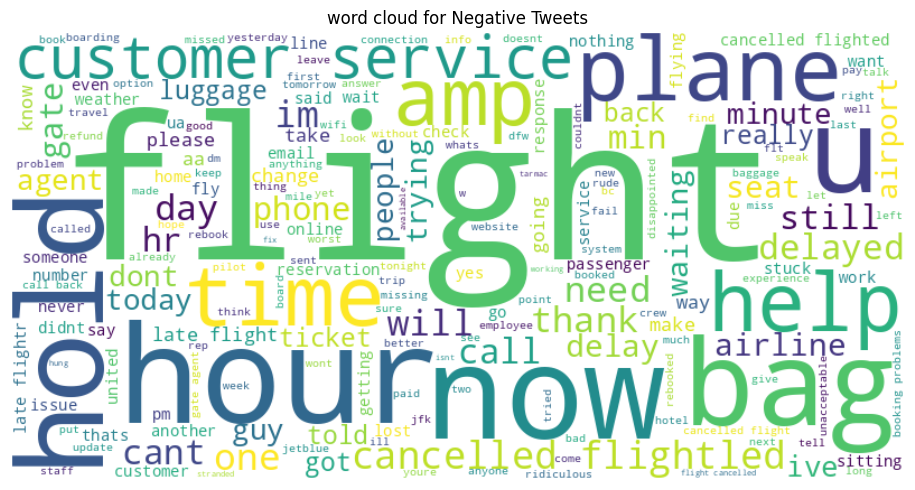

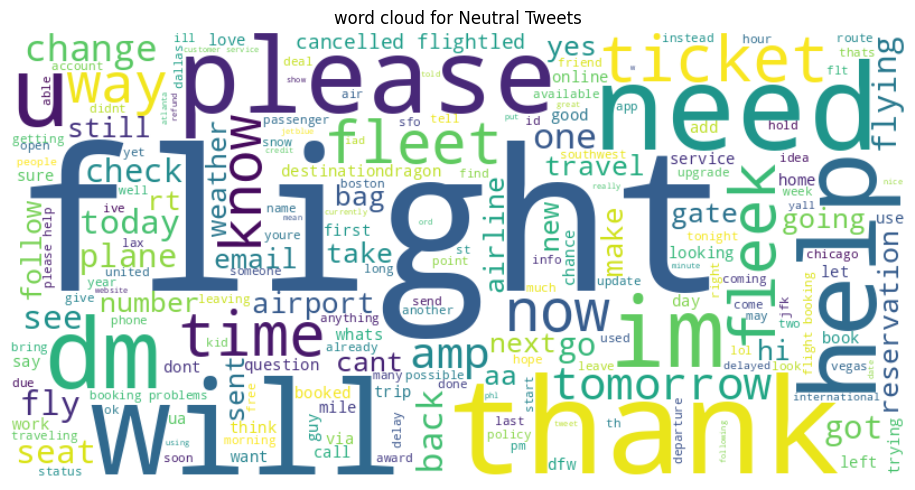

In [ ]:
from wordcloud import WordCloud

def gen_wordcloud(text, title):
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title)
  plt.axis('off')
  plt.tight_layout()
  plt.show()

for sentiment in ['positive', 'negative', 'neutral']:
  text = ' '.join(df[df['airline_sentiment'] == sentiment]['clean_text'])
  title = f'Word Cloud for {sentiment.capitalize()} Tweets'
  gen_wordcloud(text, f"word cloud for {sentiment.capitalize()} Tweets")